In [ ]:
# ---------------------------------------------------------------------------------------------------------------
# Step 1: Load the Data (Read the CSV file using pandas)
# ---------------------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------------------
# Step 2: Clean the Data (Handle missing values, remove duplicates, and fix columns if needed)
# ---------------------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------------------
# Step 3: Understand the Data (Use head(), info(), and describe() to explore the dataset)
# ---------------------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------------------
# Step 4: Identify Questions to Answer (Define the key insights we want to extract from the dataset)
# Example: Movies vs. TV Shows, content ratings, release trends, etc.
# ---------------------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------------------
# Step 5: Visualize the Data (Perform EDA using Matplotlib to create charts and answer questions visually)
# ---------------------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------------------
# Step 6: Save the Plots (Use plt.savefig() to save visualizations for reports and documentation)
# ---------------------------------------------------------------------------------------------------------------


###########################################
#              Library Usage
###########################################

# ---------------------------------------------------------------------------------------------------------------
# Step 1: pandas
# Used for data loading, data cleaning, manipulation, and exploratory data analysis.
# ---------------------------------------------------------------------------------------------------------------

# Step 2: matplotlib.pyplot
# Used for creating and customizing data visualizations and charts.
# ---------------------------------------------------------------------------------------------------------------

# Step 3: plt.bar(), plt.barh()
# Used to create vertical and horizontal bar charts for categorical comparisons.
# ---------------------------------------------------------------------------------------------------------------

# Step 4: plt.pie()
# Used to create pie charts for displaying proportions and percentage distributions.
# ---------------------------------------------------------------------------------------------------------------

# Step 5: plt.hist()
# Used to create histograms for analyzing data distributions and frequency patterns.
# ---------------------------------------------------------------------------------------------------------------

# Step 6: plt.scatter()
# Used to create scatter plots for analyzing relationships between numerical variables.
# ---------------------------------------------------------------------------------------------------------------

# Step 7: plt.subplot() / plt.subplots()
# Used to create multiple plots within a single figure for comparative analysis.
# ---------------------------------------------------------------------------------------------------------------

# Step 8: plt.tight_layout()
# Used to automatically adjust spacing and prevent overlapping plot elements.
# ---------------------------------------------------------------------------------------------------------------

# Step 9: plt.savefig()
# Used to save generated visualizations as image files for reports and documentation.
# ---------------------------------------------------------------------------------------------------------------

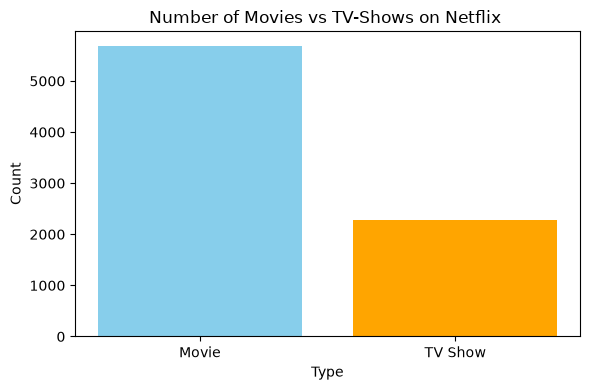

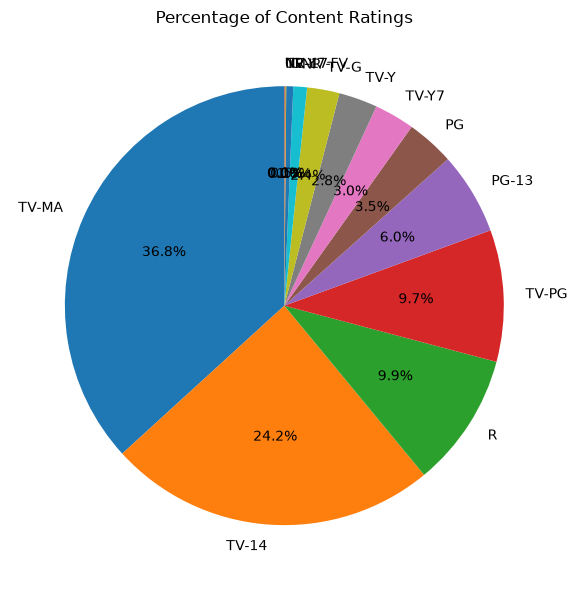

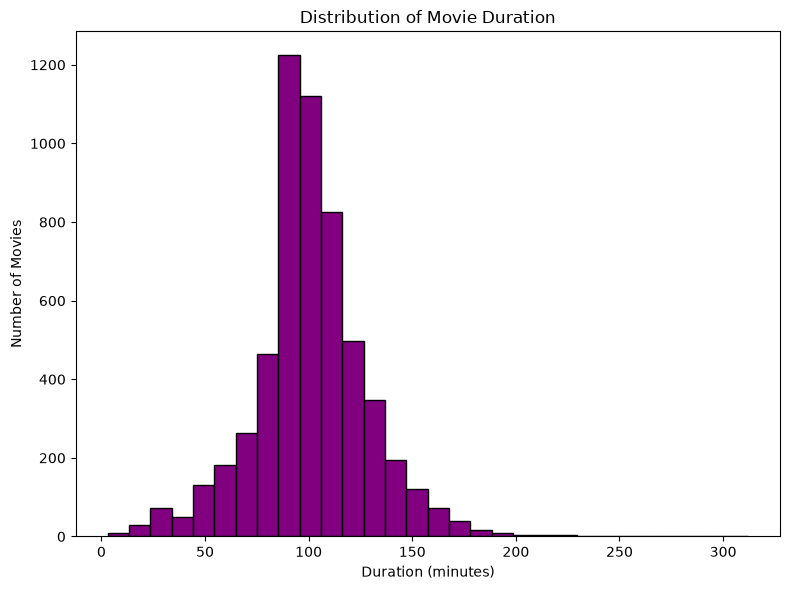

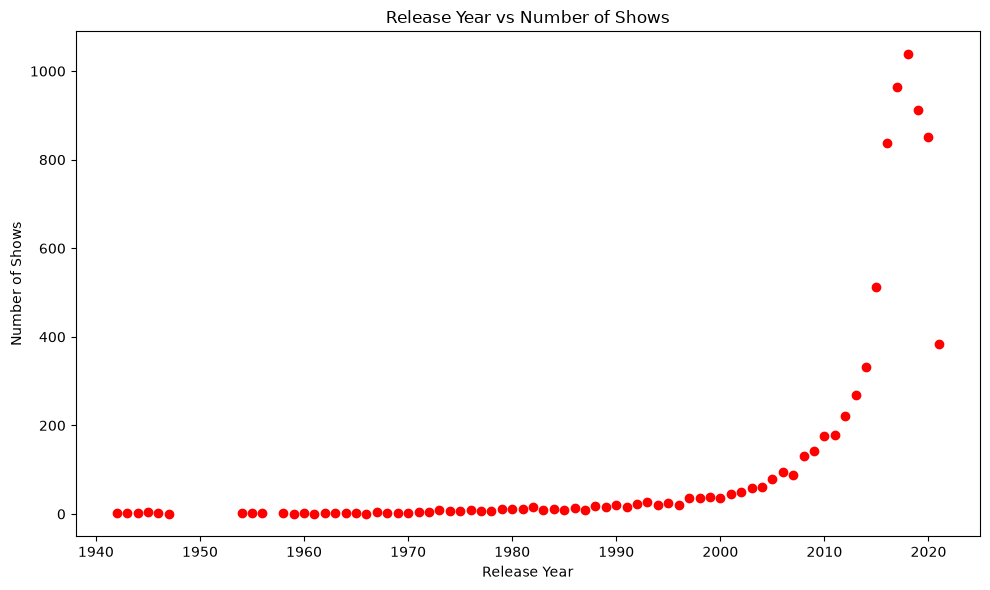

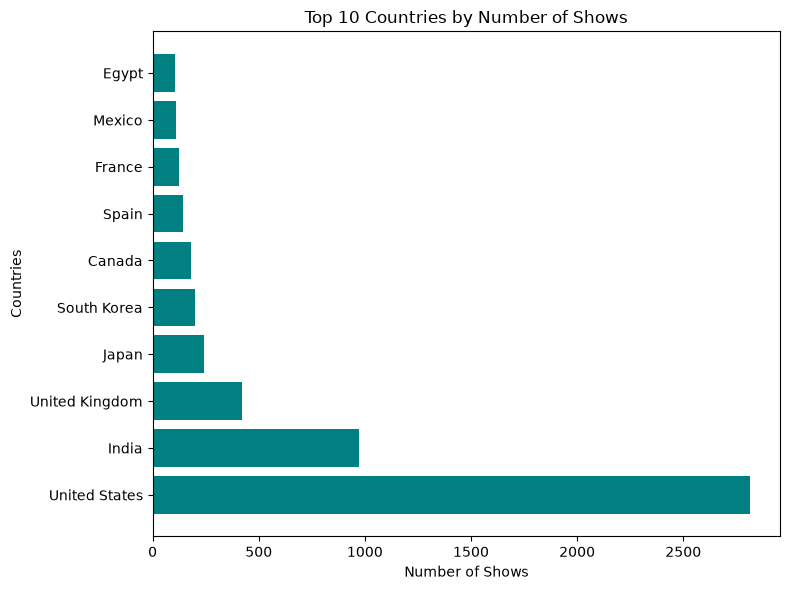

TypeError: savefig() missing 1 required positional argument: 'fname'

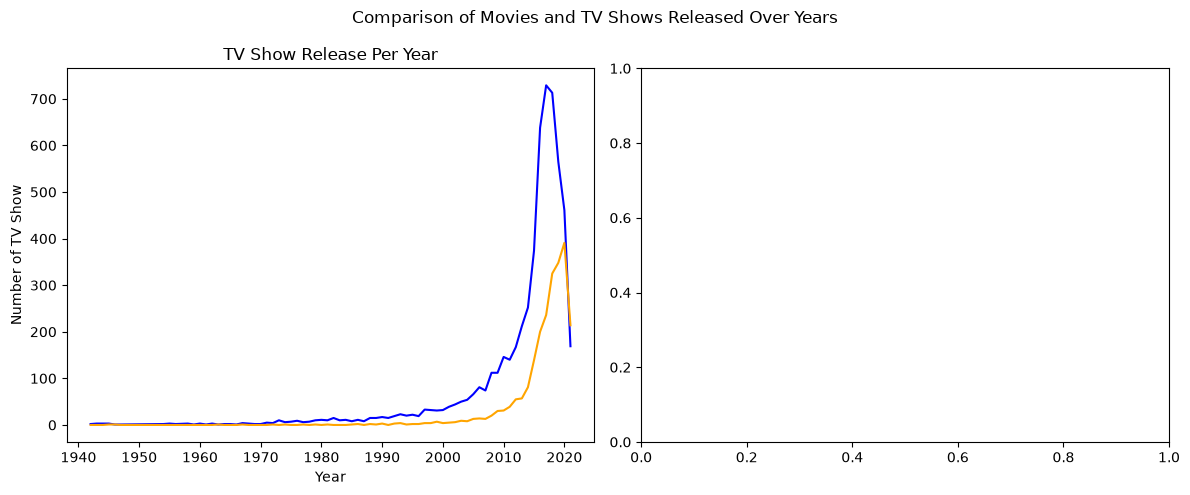

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# step-1: Load the data
df=pd.read_csv('netflix_titles.csv')

# step-2: clean the values
df=df.dropna(subset=['type','release_year','rating','country','duration'])
type_counts=df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index,type_counts.values,color=['skyblue','orange'])
plt.title('Number of Movies vs TV-Shows on Netflix ')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()


rating_counts=df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts,labels=rating_counts.index,autopct='%1.1f%%',startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

movies_df=df[df['type']=='Movie'].copy()
movies_df['duration_int']=movies_df['duration'].str.replace('min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movies_df['duration_int'], bins=30, color='purple',edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()


release_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.title('Release Year vs Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()


country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index,country_counts.values,color='teal')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Countries')
plt.tight_layout()
plt.savefig('top_10_countries.png')
plt.show()

content_by_year=df.groupby(['release_year','type']).size().unstack().fillna(0)
fig,ax=plt.subplots(1,2,figsize=(12,5))

# first sub-plots (movies)
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

# first sub-plots (TV Shows)
ax[0].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[0].set_title('TV Show Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of TV Show')

fig.suptitle('Comparison of Movies and TV Shows Released Over Years')
plt.tight_layout()
plt.savefig('movies_tv_shows.png')